# **Task 1: Data Collection & Dataset Understanding**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Teen_Mental_Health_Dataset (1).csv")

In [4]:
df.shape

(1200, 13)

In [5]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [6]:
df.dtypes

,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


# **Task 2: Data Cleaning & Preprocessing**

In [7]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


# **Task 3: Exploratory Data Analysis (EDA)**

In [10]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [11]:
df["gender"].value_counts()

,count
gender,
male,615
female,585


In [12]:
df["depression_label"].value_counts()

,count
depression_label,
0,1169
1,31


In [13]:
df.groupby("depression_label")["daily_social_media_hours"].mean()

,daily_social_media_hours
depression_label,
0,4.478785
1,6.719355


In [14]:
df.groupby("depression_label")["sleep_hours"].mean()

,sleep_hours
depression_label,
0,6.494183
1,4.761290


# **Task 4: Data Visualization**

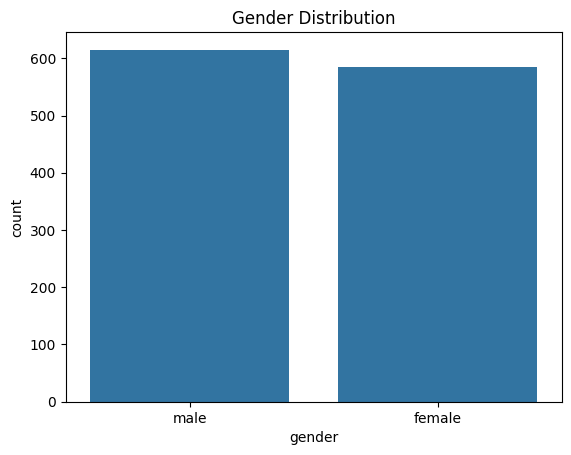

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

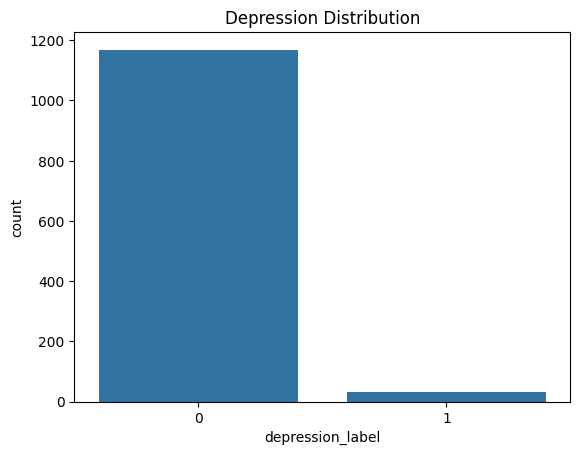

In [16]:
sns.countplot(x='depression_label', data=df)
plt.title("Depression Distribution")
plt.show()

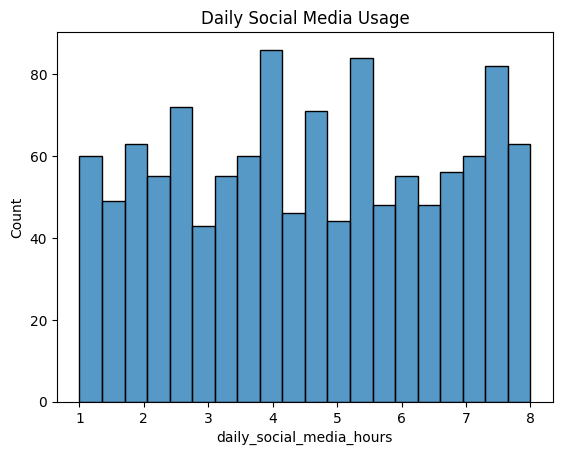

In [17]:
sns.histplot(df['daily_social_media_hours'], bins=20)
plt.title("Daily Social Media Usage")
plt.show()

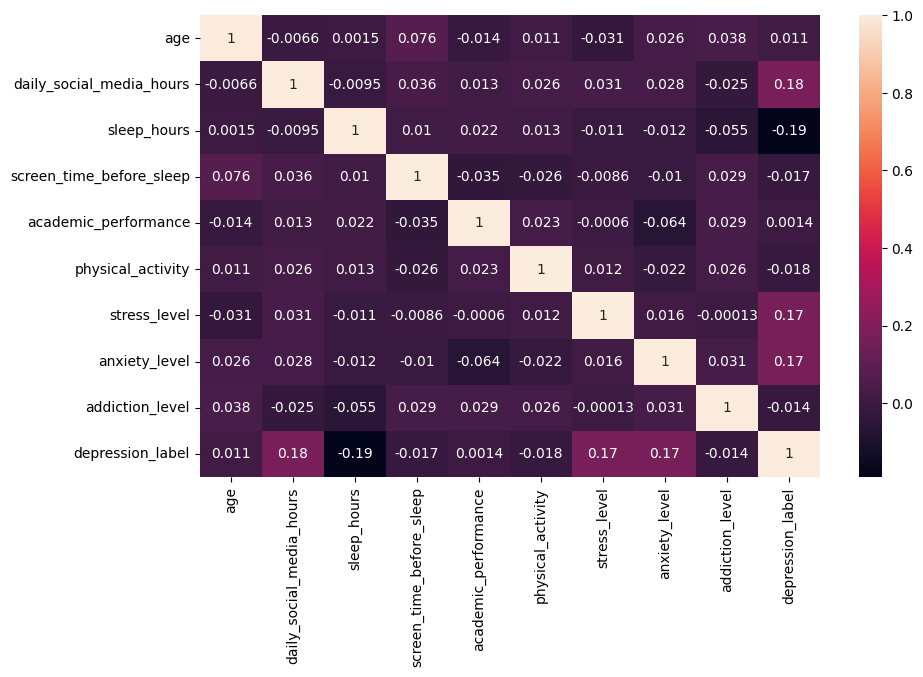

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# **Task 5: Predictive Model**

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df["platform_usage"] = le.fit_transform(df["platform_usage"])
df["social_interaction_level"] = le.fit_transform(df["social_interaction_level"])

In [24]:
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9791666666666666